Импорт библиотек

In [19]:
import pandas as pd
import numpy as np

# Инструменты для пайплайна и валидации
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Инструменты предобработки
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Модель классификации
from sklearn.neighbors import KNeighborsClassifier

# Бизнес-метрики качества
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

Подключили библиотеки pandas и numpy для работы с данными, sklearn для разбиения выборки, предобработки, моделей KNN и оценки качества (ROC-AUC, classification_report, MAE, RMSE и др.), а также matplotlib и seaborn для визуализации.

In [20]:
df = pd.read_csv('credit_card_fraud_dataset.csv')

df = df.drop(['transaction_id', 'customer_id', 'transaction_date'], axis=1)
# Удаляем transaction_id т.к. это идентификатор транзакций,
# customer_id т.к. это идентификатор пользователей
# transaction_date т.к. дата не влияет на мошенничество

#баланс классов (целевая переменная - is_fraud: 0 - не является мошенничеством, 1 - является мошенничеством)
class_counts = df['is_fraud'].value_counts(normalize=True) * 100

print(f"Баланс классов:\nНе мошенничество {class_counts[0]:.1f}%\nМошенничество {class_counts[1]:.1f}%\n")

# делим выборку 
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(df.columns)

Баланс классов:
Не мошенничество 96.2%
Мошенничество 3.8%

Index(['age', 'occupation', 'annual_income_usd', 'credit_limit_usd',
       'credit_score', 'account_age_months', 'transaction_hour',
       'transaction_amount_usd', 'merchant_category', 'device_type',
       'transaction_location', 'customer_home_city', 'distance_from_home_km',
       'is_international_transaction', 'is_new_merchant',
       'is_night_transaction', 'card_present', 'cvv_mismatch',
       'device_changed', 'avg_monthly_spend_usd', 'num_transactions_last_30d',
       'velocity_last_1h', 'failed_attempts_last_24h',
       'credit_utilization_pct', 'prev_fraud_flags', 'is_fraud'],
      dtype='str')


Удалили столбцы идентификаторов и столбец с датой, ведь идентификаторы не несут полезной информации для модели, а дата не влияет на мошенничество.

Получили результат обнаружения мошенничества в 96.2%

In [21]:
numeric_features = [
    'age', 'annual_income_usd', 'credit_limit_usd', 'credit_score',
    'account_age_months', 'transaction_hour', 'transaction_amount_usd',
    'distance_from_home_km', 'is_international_transaction', 'is_new_merchant',
    'is_night_transaction', 'card_present', 'cvv_mismatch', 'device_changed',
    'avg_monthly_spend_usd', 'num_transactions_last_30d', 'velocity_last_1h',
    'failed_attempts_last_24h', 'credit_utilization_pct', 'prev_fraud_flags'
]

categorical_features = [
    'occupation', 'merchant_category', 'device_type',
    'transaction_location', 'customer_home_city'
]
#Ветка 1: обработка чисел
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

#Ветка 2: обработка категорий (текста)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 1 + 2
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

#Итоговый конвейер: Предобработка -> Модель
clf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                      ('classifier', KNeighborsClassifier())])

param_grid = {
    'classifier__n_neighbors': [3, 5, 9],
    'classifier__weights': ['uniform', 'distance']
}

# 5-Fold кросс-валидация
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Сбор всего в одно
grid_search = GridSearchCV(estimator=clf_pipeline, param_grid=param_grid, cv=cv_strategy, scoring='roc_auc', n_jobs=1)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print(f"Лучшие параметры алгоритма: {grid_search.best_params_}")

Лучшие параметры алгоритма: {'classifier__n_neighbors': 9, 'classifier__weights': 'distance'}


Масштабируем числовые признаки через StandartScaler, категоральные через One-Hot Encoding.

Получили лучшее количество соседей - 9, и взвешиваем их по их дальности от целевой точки

In [22]:
# предскажем 0 или 1
y_pred = best_model.predict(X_test)

# Предстказание вероятностей от 0.0 до 1.0 (для ROC-AUC)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(' --- Матрица ошибок ---')
conf_matrix = confusion_matrix(y_test, y_pred)
print(f"Истинно отрицательные (TN - не мошенник, не блокируем) {conf_matrix[0][0]}")
print(f"Ложноположительные (FP - не мошенник, блокируем) {conf_matrix[0][1]}")
print(f"Ложноотрицательные (FN - мошенник, не блокируем) {conf_matrix[1][0]}")
print(f"Истинно положительные (TP - мошенник, блокируем) {conf_matrix[1][1]}")

print(' --- Отчет по метрикам ---')
print(classification_report(y_test, y_pred, target_names=['Не мошенник (0)', 'Мошенник (1)']))

roc_auc = roc_auc_score(y_test, y_proba)
print(f"Площадь под кривой ROC-AUC: {roc_auc:.4f}")

 --- Матрица ошибок ---
Истинно отрицательные (TN - не мошенник, не блокируем) 10585
Ложноположительные (FP - не мошенник, блокируем) 0
Ложноотрицательные (FN - мошенник, не блокируем) 12
Истинно положительные (TP - мошенник, блокируем) 403
 --- Отчет по метрикам ---
                 precision    recall  f1-score   support

Не мошенник (0)       1.00      1.00      1.00     10585
   Мошенник (1)       1.00      0.97      0.99       415

       accuracy                           1.00     11000
      macro avg       1.00      0.99      0.99     11000
   weighted avg       1.00      1.00      1.00     11000

Площадь под кривой ROC-AUC: 0.9952


Мы не заблокировали 12 мошенников, но заблокировали 403, что говорит об огромном проценте угадывания мошенников. Не угадали только 3%.

# Предсказание суммы кредита

In [29]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [30]:
numeric_features_reg = [
    'age', 'annual_income_usd', 'credit_limit_usd', 'credit_score',
    'account_age_months', 'transaction_hour', 'distance_from_home_km',
    'is_international_transaction', 'is_new_merchant', 'is_night_transaction',
    'card_present', 'cvv_mismatch', 'device_changed',
    'avg_monthly_spend_usd', 'num_transactions_last_30d',
    'velocity_last_1h', 'failed_attempts_last_24h',
    'credit_utilization_pct', 'prev_fraud_flags'
]

categorical_features = [
    'occupation', 'merchant_category', 'device_type',
    'transaction_location', 'customer_home_city'
]

df_reg = df.dropna(subset=numeric_features_reg + categorical_features + ['transaction_amount_usd']).copy()

X_reg = df_reg[numeric_features_reg + categorical_features]
y_reg = df_reg['transaction_amount_usd']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features_reg),
        ('cat', categorical_transformer, categorical_features)
    ]
)

reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_reg),
    ('knn_reg', KNeighborsRegressor())
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
param_dist = {
    'knn_reg__n_neighbors': np.arange(3, 30),
    'knn_reg__weights': ['uniform', 'distance']
}

random_search = RandomizedSearchCV(estimator=reg_pipeline, param_distributions=param_dist, n_iter=10, cv=kf, scoring='neg_mean_absolute_error', n_jobs=1, random_state=42)
random_search.fit(X_train_r, y_train_r)
best_reg = random_search.best_estimator_

print(f"Лучшие параметры регрессора: {random_search.best_params_}")

Лучшие параметры регрессора: {'knn_reg__weights': 'distance', 'knn_reg__n_neighbors': np.int64(12)}


Целевая переменная transaction_amount_usd, убрали её с признаков, чтобы не было утечки данных. 

Получили лучшие параметры для регрессора: 12 соседей и взвешиваем их в зависимости от расстояния до целевой точки

In [31]:
y_pred_r = best_reg.predict(X_test_r)
def smape(y_test, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_test) / (np.abs(y_test) + np.abs(y_pred)))

mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_r, y_pred_r)
smape_value = smape(y_test_r, y_pred_r)

print(' --- Отчёт по метрикам регрессии ---')
print(f"MSE (квадратные $): {mse:,.0f}")
print(f"RMSE ($): {rmse:,.0f}")
print(f"MAE ($): {mae:,.2f}")
print(f"SMAPE (ошибка в %): {smape_value:,.2f}%")

 --- Отчёт по метрикам регрессии ---
MSE (квадратные $): 355,679
RMSE ($): 596
MAE ($): 306.67
SMAPE (ошибка в %): 51.14%


Модель ошибается в среднем на 306.67$

RMSE показывается что модель сильнее штрафует крупные отклонения

SMAPE показывает что ошибка на маленьких суммах довольно большая

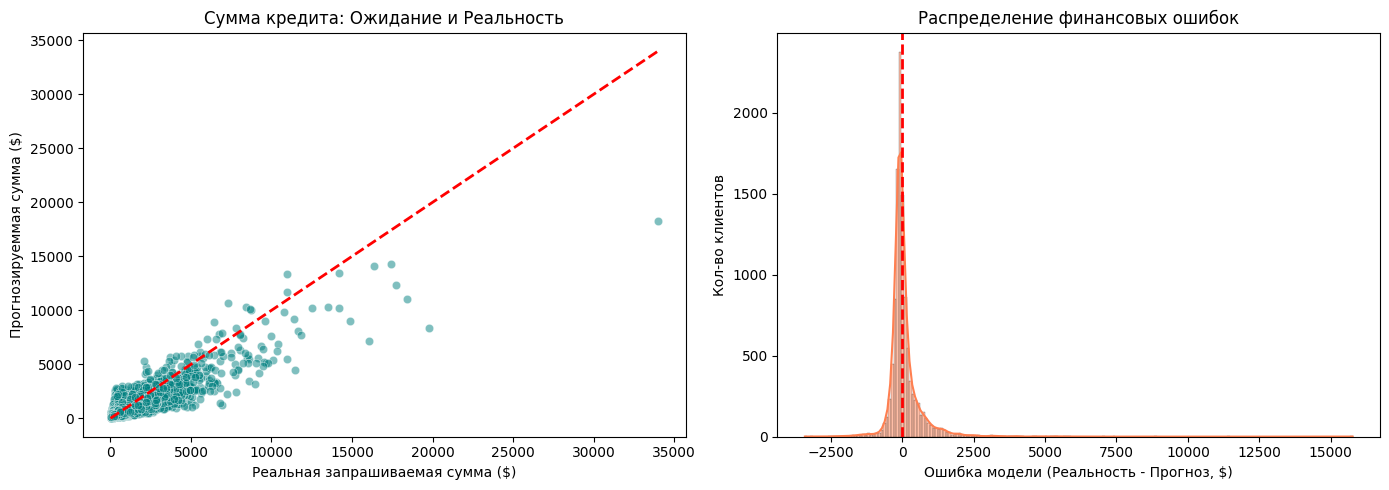

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_test_r, y=y_pred_r, alpha=0.5, color='teal', ax=axes[0])
y_min = min(y_test_r.min(), y_pred_r.min())
y_max = max(y_test_r.max(), y_pred_r.max())
axes[0].plot([y_min, y_max], [y_min, y_max], 'r--', lw=2)


axes[0].set_title("Сумма кредита: Ожидание и Реальность")
axes[0].set_xlabel("Реальная запрашиваемая сумма ($)")
axes[0].set_ylabel("Прогнозируеммая сумма ($)")

# 2 График: Распределение ошибок
residuals = y_test_r - y_pred_r
sns.histplot(residuals, kde=True, color='coral', ax=axes[1])
axes[1].axvline(x=0, color='red', linestyle="--", lw=2) # Линия нулевой ошибки
axes[1].set_title("Распределение финансовых ошибок")
axes[1].set_xlabel("Ошибка модели (Реальность - Прогноз, $)")
axes[1].set_ylabel("Кол-во клиентов")

plt.tight_layout()
plt.show()

Модель хорошо предсказыват мошенников по запросам денег до 5 000$, после этой суммы разброс становится слишком большим для точных предсказаний.

Модель хорошо предсказывает небольшие мошенничества, для более крупных нужно участвование человека